In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('display.max_colwidth', None)
df = pd.read_csv("hf://datasets/ukr-detect/ukr-toxicity-dataset/train.tsv", sep="\t")


e:\Toxic-Guard-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df[df['toxic'] == 1]

,text,toxic
2500,І ніхуяшеньки їй за те не буде.,1
2501,"Я знала, що вся ця шобла зараз активізується.",1
2502,"Адже зовнішність людини ніяк не винна, що вона в душі просто уєбан.",1
2503,"а цитую ""в пізду м'ютити"" культурно?)",1
2504,Найгірші відчуття - то коли спадають штани і коли життя котиться в їбєня.,1
...,...,...
4995,Несіть мені усі по три рубля і мудрості вам дам я дохуя.,1
4996,бля( я думала приїду в Київ і ще встигну щось норм знайти,1
4997,Гаррі Поттер і різна цікава хуйня.,1
4998,На пєйсбуці так само годують гівном?,1


In [4]:
df[df['toxic'] == 0]

,text,toxic
0,"У дворі роблять дорогу, починають шуміти о 8-й ранку, але приємно, що нарешті її роблять!!!",0
1,І знову дві години на прокидання.,0
2,"Хочу заплющити очі, розплющити - і вже все стало нормально.",0
3,Ваш ділер годних серіалів приніс вам особливий товар.,0
4,"Тому він блукає по світу зі світильником, шукає куди приткнутися.",0
...,...,...
2495,"#ЛяЗберігає Бож, я і так нічого не розумію, боюся, що не люблю, а мені це ще й доводять...",0
2496,Справедливості заради: мене нервує більша частина людства.,0
2497,все не виходить з голови розмова ...з другом? не знаю чи і друг. особлива людина в житті.,0
2498,"Одним словом не сподобалася, коли їси викликає блювотний рефлекс :(",0


In [7]:
df.toxic.value_counts()

toxic
0    2500
1    2500
Name: count, dtype: int64

In [8]:
df.isnull().sum()

text     0
toxic    0
dtype: int64

## Бачимо ,що у нас невеликий датасет а також наші класи збалансовані

##

In [3]:
df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=42,stratify=df['toxic'])

df_train, df_val = train_test_split(df_train_val, test_size=0.125, random_state=42,stratify=df_train_val['toxic'])



df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [10]:
df_train

,text,toxic
0,"Виходить для різних ""я"" треба різні блоги))",0
1,"Мама відмила рондилі, способом від Читайте #блог",0
2,"Еее, люблю цей тип ""патріотів"", що форсять прийняття російських законів та культури в Україні.",0
3,"Та нє, твоє хуйня, в мене вже імунітєт",1
4,та пиздец просто йду поплачу чи що,1
...,...,...
3495,"Ну бля, тим тільки гірше роблять Я розумію, чого вони то роблять Но бісить ужасно",1
3496,"Мама говорила шо я самий умний і самий красівий, но я то знаю шо то все піздьож (с) Сірьожа",1
3497,"а мені скоро переїздити, ну бля",1
3498,Хочу хуярити людей палками до кривавих сліз.,1


In [11]:
df_val 

,text,toxic
0,"боюся що буде постити фігню типу: ""відвідав свиноферму в селі Сраколюбки, привітав доярку Параску Іванчук з рекордним надоєм"" :\",0
1,"Сподіваюсь, що коли повернуся до Києва, Подільський недоміст нахер завалиться і приб'є всіх рейверів у скейт-парку на Рибальському",1
2,"#Imaginaerum дуже цікавий альбом, дещо божевільний з краплинкою веселої їбанутості.",1
3,"Астронавт – це той, хто здійснив політ на борту американського корабля.",0
4,"бля, ну як можна захворіти в таку погоду!!!!????",1
...,...,...
495,"Китайці, нагадаю, купували ""Варяг"" під казино.",0
496,"«Спати блять» — чарівне закляття, котре змушує оточуючих зрозуміти, що ліпше вас не рухати.",1
497,"Сука, я проїбала можливість львівської прописки.",1
498,"Нормальні, адекватні та порядні люди, які зараз працюють у поліції (я знаю, що ви є), я вам дуже співчуваю.",0


In [12]:
df_test


,text,toxic
0,для них мав настати особливий час і от сьогодні вони самі покликали :),0
1,Але ці підари зазіхнули на святе!,1
2,"Залишала на смітнику стару улюблену сумку, а відчуття наче домашнього улюбленця",0
3,"Не бійтесь посилати нахуй людей, без яких, вам здається, не прожити.",1
4,Ніщо так не видає твою істинну сутність як твої їбануті друзі.,1
...,...,...
995,"Срати навчіться штани знімаючи і сраку підтирати бамагою, а не пальцем, а там побалакаємо за парламентську республіку.",1
996,"Ну морда у нього задоволена, тож напевно не відпиляв",1
997,"ІРА - це не лише Ірландська республіканська армія""",0
998,"Якби диявол існував, він би заново створив чудовий секс з хуйовою людиною та мучив би ним до скону.",1


In [13]:
print(f'Розмір всього датасета: {len(df)}')

print(f'Train: {len(df_train)} ({len(df_train)/len(df) * 100}%)')
print(f'Validation: {len(df_val)} ({len(df_val)/len(df) * 100}%)')
print(f'Test: {len(df_test)} ({len(df_test)/len(df) * 100}%)')

Розмір всього датасета: 5000
Train: 3500 (70.0%)
Validation: 500 (10.0%)
Test: 1000 (20.0%)


In [14]:
df_train

,text,toxic
0,"Виходить для різних ""я"" треба різні блоги))",0
1,"Мама відмила рондилі, способом від Читайте #блог",0
2,"Еее, люблю цей тип ""патріотів"", що форсять прийняття російських законів та культури в Україні.",0
3,"Та нє, твоє хуйня, в мене вже імунітєт",1
4,та пиздец просто йду поплачу чи що,1
...,...,...
3495,"Ну бля, тим тільки гірше роблять Я розумію, чого вони то роблять Но бісить ужасно",1
3496,"Мама говорила шо я самий умний і самий красівий, но я то знаю шо то все піздьож (с) Сірьожа",1
3497,"а мені скоро переїздити, ну бля",1
3498,Хочу хуярити людей палками до кривавих сліз.,1


In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pickle
import os


In [5]:
def get_embeddings_from_texts(texts, model_name='intfloat/multilingual-e5-small'):
    model = SentenceTransformer(model_name,device=0)
    return model.encode(texts)

### Застосовуємо функцію get_embeddings_from_texts до данних X_train, X_val, X_test и зберігаємо у папки 

In [ ]:
X_train = get_embeddings_from_texts(df_train.text.astype(str).tolist())
X_val = get_embeddings_from_texts(df_val.text.astype(str).tolist())
X_test = get_embeddings_from_texts(df_test.text.astype(str).tolist())

y_train = df_train.toxic.values
y_val = df_val.toxic.values
y_test = df_test.toxic.values


current_dir = os.getcwd()

project_root = os.path.dirname(current_dir) 

# Будуємо абсолютний шлях до data/processed
processed_dir = os.path.join(project_root, 'data', 'processed')

np.save(os.path.join(processed_dir, 'X_train.npy'), X_train)
np.save(os.path.join(processed_dir, 'X_val.npy'), X_val)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test)


np.save(os.path.join(processed_dir, 'y_train.npy'), y_train)
np.save(os.path.join(processed_dir, 'y_val.npy'), y_val)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test)



rag_texts = pd.concat([df_train, df_val], ignore_index=True)['text'].astype(str).tolist()
with open(os.path.join(processed_dir, 'rag_texts.pkl'), 'wb') as f:
    pickle.dump(rag_texts, f)





In [24]:
processed_dir_raw = os.path.join(project_root, 'data', 'raw')
df.to_csv(os.path.join(processed_dir_raw, 'original_comments.csv'), index=False)

## Тепер проводимо эксперименты з моделями

In [6]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

In [7]:
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir) 
processed_dir = os.path.join(project_root, 'data', 'processed')

In [7]:
processed_dir

'e:\\Toxic-Guard-RAG\\data\\processed'

In [8]:
X_train = np.load(os.path.join(processed_dir, 'X_train.npy'))
y_train = np.load(os.path.join(processed_dir, 'y_train.npy'))

X_val = np.load(os.path.join(processed_dir, 'X_val.npy'))
y_val = np.load(os.path.join(processed_dir, 'y_val.npy'))


In [9]:
X_train.shape

(3500, 384)

In [10]:
y_train.shape

(3500,)

## Протестуємо 4 моделі з яких 2 це лінійні моделі і інщі дві це моделі градієнтного бустінгу

Назва моделі: LogisticRegression
Fitting 5 folds for each of 6 candidates, totalling 30 fits


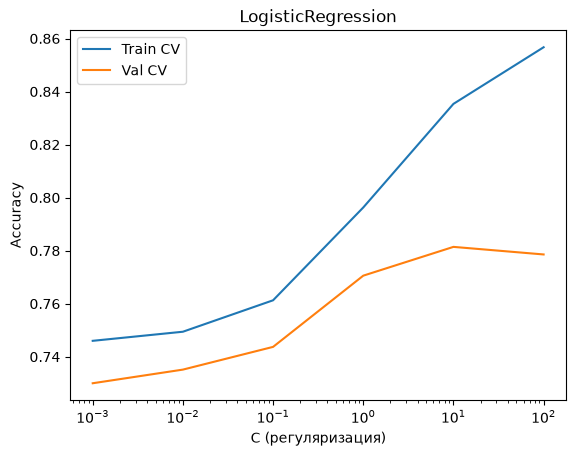

  Лучшие параметры для LogisticRegression: {'C': 10}
   Точность на Валидации: 0.8060
Назва моделі: LinearSVC
Fitting 5 folds for each of 6 candidates, totalling 30 fits


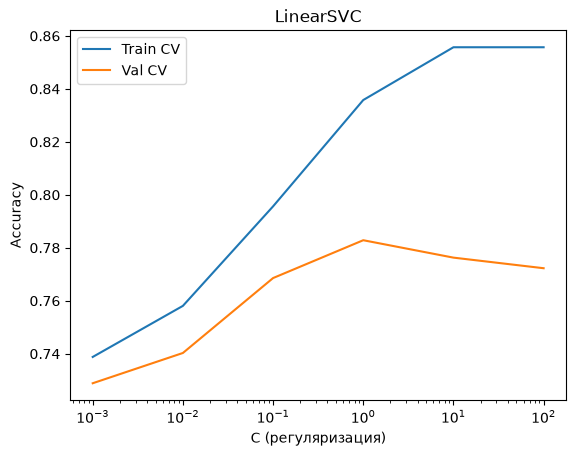

  Лучшие параметры для LinearSVC: {'C': 1}
   Точность на Валидации: 0.8120
Назва моделі: CatBoostClassifier
Fitting 5 folds for each of 30 candidates, totalling 150 fits


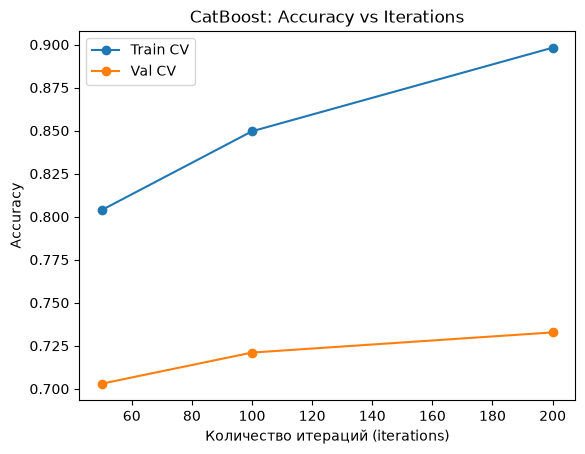

  Лучшие параметры для CatBoostClassifier: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
   Точность на Валидации: 0.7820
Назва моделі: LGBMClassifier
Fitting 5 folds for each of 30 candidates, totalling 150 fits


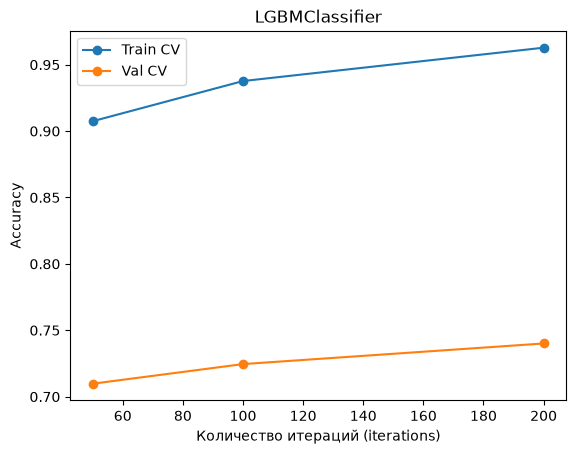

  Лучшие параметры для LGBMClassifier: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 31}
   Точность на Валидации: 0.7740

Победитель по валидации:
Лучшая модель: LinearSVC с точностью 0.8120


In [ ]:

models_params = {
    'LogisticRegression': {'model':LogisticRegression(max_iter=1000,random_state=42), 
                           'params': {'C':[0.001, 0.01, 0.1, 1, 10, 100]}
                            },
    'LinearSVC': {'model':LinearSVC(max_iter=1000,random_state=42), 
                   'params': {'C':[0.001, 0.01, 0.1, 1, 10, 100]}
                    },

    'CatBoostClassifier': {'model': CatBoostClassifier(verbose=0, random_state=42),
                            'params':{'iterations': [50, 100, 200], 'depth': [3,4,5,6, 8], 'learning_rate': [0.01, 0.1]}
                            },

    'LGBMClassifier': {'model': LGBMClassifier(verbose=-1, random_state=42),
                       'params': {'n_estimators': [50, 100, 200], 
                                  'num_leaves': [10,15,20, 31, 50], 
                                  'learning_rate': [0.01, 0.1]}
                       }
}


best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, config in models_params.items():
    print(f"Назва моделі: {name}")

    grid_search = GridSearchCV(estimator=config['model'], param_grid=config['params'], cv=cv, scoring='accuracy', verbose=1,return_train_score=True)

    grid_search.fit(X_train,y_train)

    best_models[name] = grid_search.best_estimator_

    results = grid_search.cv_results_

    if name  == 'LogisticRegression' or name == 'LinearSVC':
        plt.plot(results['param_C'], results['mean_train_score'], label='Train CV')
        plt.plot(results['param_C'], results['mean_test_score'], label='Val CV')
        plt.title(name)
        plt.xscale('log')
        plt.xlabel('C (регуляризація)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.show()
    elif name == 'CatBoostClassifier':
        results_df = pd.DataFrame(results)
        grouped = results_df.groupby('param_iterations')[['mean_train_score', 'mean_test_score']].mean()

        plt.plot(grouped.index, grouped['mean_train_score'], label='Train CV', marker='o')
        plt.plot(grouped.index, grouped['mean_test_score'], label='Val CV', marker='o')
        plt.xlabel('Кількість ітерацій (iterations)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('CatBoost: Accuracy vs Iterations')
        plt.show()
    else:
        results_df = pd.DataFrame(results)
        grouped = results_df.groupby('param_n_estimators')[['mean_train_score', 'mean_test_score']].mean()
        
        plt.plot(grouped.index, grouped['mean_train_score'], label='Train CV', marker='o')
        plt.plot(grouped.index, grouped['mean_test_score'], label='Val CV', marker='o')
        plt.title(name)
        plt.xlabel('Количество итераций (iterations)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.show()



    val_acc = accuracy_score(y_val, best_models[name].predict(X_val))
    print(f"  Лучшие параметры для {name}: {grid_search.best_params_}")
    print(f"   Точность на Валидации: {val_acc:.4f}")



print("\nПобедитель по валидации:")
best_name = max(best_models, key=lambda name: accuracy_score(y_val, best_models[name].predict(X_val)))
print(f"Лучшая модель: {best_name} с точностью {accuracy_score(y_val, best_models[best_name].predict(X_val)):.4f}")


In [14]:
models_params = {
    'RandomForestClassifier': {'model':RandomForestClassifier(random_state=42), 
                           'params': {'n_estimators':[50, 100, 200], 'max_depth':[3, 5, 10, 15], 
                                      'min_samples_split': [2, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                    'max_features': ['sqrt', 'log2']}
                            }}

Назва моделі: RandomForestClassifier
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


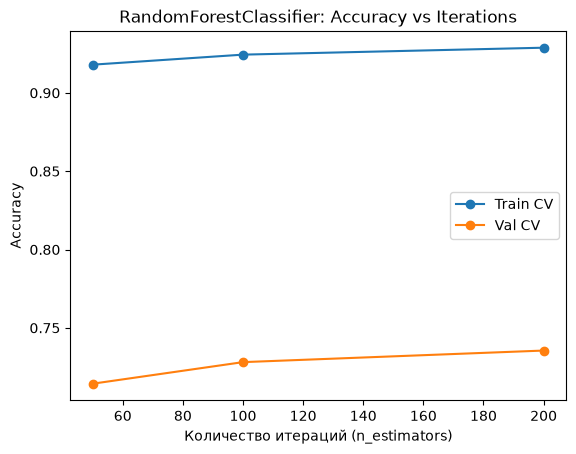

  Лучшие параметры для RandomForestClassifier: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
   Точность на Валидации: 0.7780


In [ ]:
best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, config in models_params.items():
    print(f"Назва моделі: {name}")

    grid_search = GridSearchCV(estimator=config['model'], param_grid=config['params'], cv=cv, scoring='accuracy', verbose=1,return_train_score=True)

    grid_search.fit(X_train,y_train)

    best_models[name] = grid_search.best_estimator_

    results = grid_search.cv_results_


    results_df = pd.DataFrame(results)
    grouped = results_df.groupby('param_n_estimators')[['mean_train_score', 'mean_test_score']].mean()

    plt.plot(grouped.index, grouped['mean_train_score'], label='Train CV', marker='o')
    plt.plot(grouped.index, grouped['mean_test_score'], label='Val CV', marker='o')
    plt.xlabel('Кількість ітераций (n_estimators)')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('RandomForestClassifier: Accuracy vs Iterations')
    plt.show()


    val_acc = accuracy_score(y_val, best_models[name].predict(X_val))
    print(f"  Лучшие параметры для {name}: {grid_search.best_params_}")
    print(f"   Точность на Валидации: {val_acc:.4f}")

## Бачимо, що у лінійних моделей точність на валідаціії є найвищею.

LogisticRegression
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       250
           1       0.81      0.80      0.80       250

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.81      0.81      0.81       500

LinearSVC
              precision    recall  f1-score   support

           0       0.81      0.82      0.81       250
           1       0.81      0.81      0.81       250

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.81      0.81      0.81       500



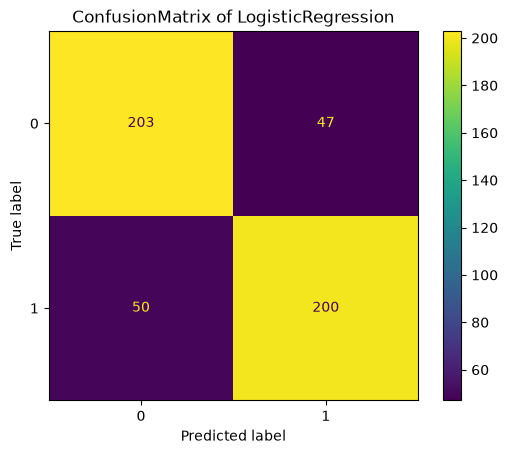

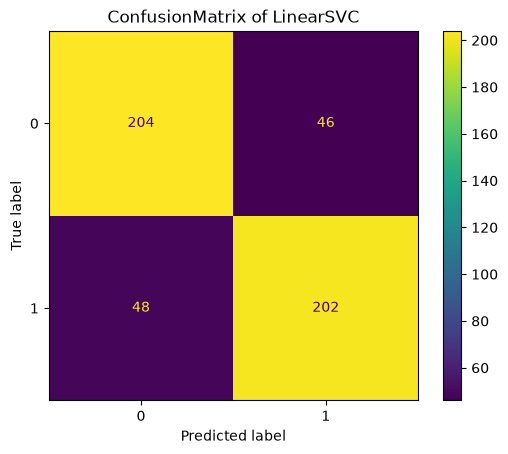

In [9]:
log_model = LogisticRegression(max_iter=1000, C = 10)
log_model.fit(X_train,y_train)
log_pred = log_model.predict(X_val)

print('LogisticRegression')
print(classification_report(y_val, log_pred))
ConfusionMatrixDisplay.from_predictions(y_val,log_pred)
plt.title('ConfusionMatrix of LogisticRegression');

svc_model = LinearSVC(max_iter=1000, C = 1)
svc_model.fit(X_train,y_train)
svc_pred = svc_model.predict(X_val)

print('LinearSVC')
print(classification_report(y_val, svc_pred))
ConfusionMatrixDisplay.from_predictions(y_val,svc_pred)
plt.title('ConfusionMatrix of LinearSVC');



## Ми бачимо , що моделі дуже схожі а також бачимо f1-score для моделі LogisticRegression для класа 1 дорівнює  0.81 а для класа 0 -  0.80
## Це означает ,що наша модель однаково добре може розрізняти  хороші і погані коментарі 

# Але наша місія це отримати Precision >= 0.95 для класа 1,  а наші моделі мають 0.81 

In [10]:
precision, recall, thresholds = precision_recall_curve(y_val, log_model.predict_proba(X_val)[:,1])

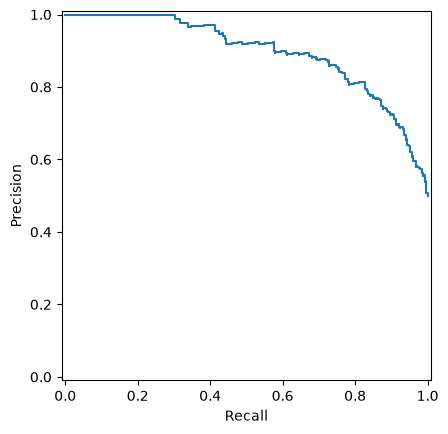

In [11]:
PrecisionRecallDisplay(precision=precision,recall=recall).plot()

## Дивлячись на цей график то можно побачити ,що можно отримати precision = 1.0 та Recall = 0.3. Це означає ,що  наша модель буде дуже акуратна і буде видаляти коментарі тільки тоді коли вона дуже сильно впевнена. В такому випадку ми більшість поганих коментарів видаляти не будемо. Тобто приблизно 30% ми будемо видаляти поганих коментарів но ми точно  не видалемо хороший коментар

In [12]:
np.where(precision >= 0.95)

(array([389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401,
        402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414,
        415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427,
        428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440,
        441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453,
        454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466,
        467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479,
        480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492,
        493, 494, 495, 496, 497, 498, 499, 500]),)

In [13]:
np.where(precision >= 0.92)

(array([344, 345, 346, 347, 348, 349, 350, 355, 356, 357, 358, 359, 360,
        361, 362, 368, 369, 370, 371, 372, 373, 374, 375, 380, 381, 382,
        383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395,
        396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408,
        409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421,
        422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434,
        435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447,
        448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460,
        461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473,
        474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486,
        487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499,
        500]),)

In [14]:
thresholds[389]

np.float32(0.80886066)

In [14]:
print(classification_report(y_val, log_model.predict_proba(X_val)[:,1] >= thresholds[389]))

              precision    recall  f1-score   support

           0       0.63      0.98      0.77       250
           1       0.95      0.42      0.59       250

    accuracy                           0.70       500
   macro avg       0.79      0.70      0.68       500
weighted avg       0.79      0.70      0.68       500



## Дивлячись на цей classification report, бачимо, що ми досягли мети де precision = 95, але у нас сильно впав recall = 42, так як у нас сбалансований клас , то треба подивитися на різницю між f1-score для 0 класа та для класe 1 .Бачимо, що ця різниця становить 18% (0.77 для класу 0 проти 0.59 для класу 1). Це дуже великий перекіс. Модель надто сильно «перестраховується» і фактично ігнорує складні або неочевидні токсичні коментарі, щоб випадково не заблокувати нормального користувача. Тому я вирішив опустити поріг до рівня, де Precision = 0.92. Це зменшило різницю F1 до 9% (0.80 vs 0.71) і підняло Recall з 0.42 до 0.58.

In [15]:
print(classification_report(y_val, log_model.predict_proba(X_val)[:,1] >= thresholds[344]))

              precision    recall  f1-score   support

           0       0.69      0.95      0.80       250
           1       0.92      0.58      0.71       250

    accuracy                           0.76       500
   macro avg       0.81      0.76      0.76       500
weighted avg       0.81      0.76      0.76       500



## Дивлячись на цей звіт, ми бачимо значно кращий баланс між класами. Різниця між F1-score для класу 0 та класу 1 становить 9% (0.80 проти 0.71), що є прийнятним показником для збалансованого датасету (порівняно з 18% у попередньому варіанті).

## Precision для класу 1 залишається високим - 0.92, при цьому Recall зріс до 0.58, що дозволяє нам знаходити на 16% більше токсичних коментарів. Також варто зазначити, що Accuracy (0.76) та Macro avg F1 (0.76) збігаються. Це підтверджує, що модель працює чесно, без сильного перекосу в бік одного з класів.

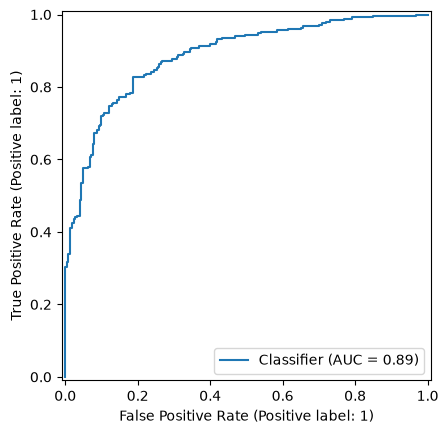

In [16]:
RocCurveDisplay.from_predictions(y_val, log_model.predict_proba(X_val)[:,1])

## Цей графік ROC-AUC показує загальну здатність моделі розрізняти класи незалежно від обраного порогу. Значення AUC = 0.89 є дуже хорошим результатом. Оскільки в нашому датасеті класи збалансовані, ця метрика є об'єктивною та стабільною, тому ми можемо спокійно використовувати цю модель для подальшої роботи.

In [17]:
X_test = np.load(os.path.join(processed_dir, 'X_test.npy'))
y_test = np.load(os.path.join(processed_dir, 'y_test.npy'))

final_thresholds = thresholds[344]

y_test_proba = log_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_proba >= final_thresholds)


print(classification_report(y_test,y_test_pred))



              precision    recall  f1-score   support

           0       0.72      0.91      0.80       500
           1       0.87      0.64      0.74       500

    accuracy                           0.77      1000
   macro avg       0.79      0.77      0.77      1000
weighted avg       0.79      0.77      0.77      1000



## Фінальна перевірка на тестовому наборі підтвердила стабільність моделі. Хоча Precision впав з 0.92 на валідації до 0.87 на тесті, Recall піднявся до 0.64, а F1-gap скоротився до 6%. Це абсолютно прийнятний дрейф для нових даних. 

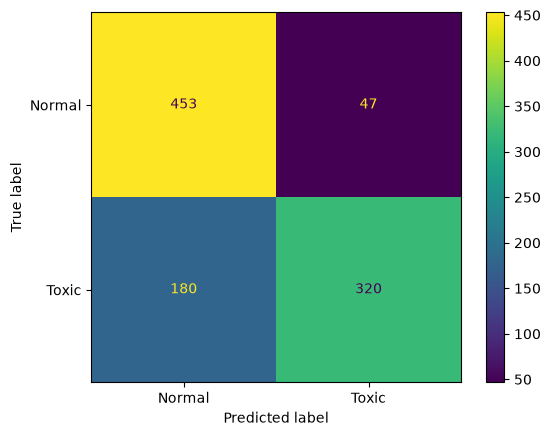

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,display_labels=['Normal', 'Toxic'])

In [19]:
from collections import Counter
from sklearn.dummy import DummyClassifier

In [21]:
y_train

array([0, 0, 0, ..., 1, 1, 1], shape=(3500,))

In [20]:
dummy_clf = DummyClassifier(strategy='most_frequent',random_state=42)
dummy_clf.fit(X_train,y_train)

y_dummy_pred = dummy_clf.predict(X_test)

In [21]:
print(classification_report(y_test,y_dummy_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       500
           1       0.00      0.00      0.00       500

    accuracy                           0.50      1000
   macro avg       0.25      0.50      0.33      1000
weighted avg       0.25      0.50      0.33      1000



e:\Toxic-Guard-RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Toxic-Guard-RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Toxic-Guard-RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Бачимо ,що базова модель (яка завжди передбачає найпоширеніший клас) має Accuracy лише 0.50, а Precision та Recall для токсичного класу (1) дорівнюють 0.00. Це підтверджує, що моя логістична регресія дійсно навчилася корисним закономірностям, а не просто вгадує.

In [22]:
fn_id = np.where((y_test == 1) & (y_test_pred == 0))[0]


In [23]:
print(f"False Negative: {len(fn_id)}")

for index in fn_id:
    print(f"Скор від моделі: {y_test_proba[index]}")
    print(f"Текст: {df_test['text'][index]}")
    print("-"*100)

False Negative: 180
Скор від моделі: 0.5732067823410034
Текст: Але ці підари зазіхнули на святе!
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.5958094000816345
Текст: Ніщо так не видає твою істинну сутність як твої їбануті друзі.
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.5548858642578125
Текст: Кому це куди впиралось, якщо можна сидіти придумувати твіти про шлюх.
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.4922678768634796
Текст: висновок: дуже затягнуто, дуже багато непотрібних паралелей, хоча є й дуже класні. виїбати нікого після перегляду не захотілося
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.6368340253829956
Текст: така блятт моя доля чи що
----------------------------------------

## Цей вивід показує реально токсичні коментарі, які модель пропустила через низьку впевненість. Скори моделі для цих коментарів становлять низькі значення що значно нижче за встановлений поріг (~0.70). Це коментарі з прихованим матом або специфічним сарказмом, які модель не змогла розпізнати через складність контексту.

In [24]:
fp_id = np.where((y_test == 0) & (y_test_pred == 1))[0]

In [103]:
df_test.iloc[23]

text     Страшенно не люблю фрази "з ноги вибиваю двері".
toxic                                                   0
Name: 23, dtype: object

In [25]:
print(f"False Positive: {len(fp_id)}")

for index in fp_id:
    print(f"Скор від моделі: {y_test_proba[index]}")
    print(f"Текст: {df_test['text'][index]}")
    print("-"*100)

False Positive: 47
Скор від моделі: 0.7081764340400696
Текст: Страшенно не люблю фрази "з ноги вибиваю двері".
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.7734436392784119
Текст: Класненько, коли твій пост стирений в Пікабу і закинутий  в групу універу зібрав дофіга лайків
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.7290462255477905
Текст: Страшні заметілі, сніг січе обличчя, ідучи по коліна провалююся в сніг...
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.8049208521842957
Текст: Знаєте, терплю то хамство в Україні від людей, терплю.
----------------------------------------------------------------------------------------------------
Скор від моделі: 0.7244210839271545
Текст: Цікаво чому кожного разу перед відпусткою на роботі срака, ще й така непердбачувана
-----

## Цей вивід ілюструє хибні спрацьовування. Модель дає цим нормальним коментарям дуже високі скори (0.71, 0.85, 0.87), помилково приймаючи саркастичні висловлювання або нестандартну лексику за токсичні. Це є ціною, яку ми платимо за встановлений високий поріг для захисту нормальних користувачів від випадкових блокувань.

In [26]:
import joblib
import json
import faiss

In [30]:
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir) 
processed_dir_models= os.path.join(project_root, 'models')

In [31]:
os.path.join(processed_dir_models)

'e:\\Toxic-Guard-RAG\\models'

In [29]:
joblib.dump(log_model, os.path.join(processed_dir,'classifier_model.joblib'))

final_config = {
    'model_name': 'intfloat/multilingual-e5-small', 
    'threshold': float(final_thresholds)              
}

with open(os.path.join(processed_dir,'config.json'), 'w') as f:
    json.dump(final_config, f)

In [37]:
processed_dir = os.path.join(project_root,'data', 'processed')
X_train = np.load(os.path.join(processed_dir, 'X_train.npy'))
X_val = np.load(os.path.join(processed_dir, 'X_val.npy'))

X_rag = np.vstack((X_train, X_val))
print(f"Розмір бази для FAISS: {X_rag.shape}")


dimension = X_rag.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)

faiss_index.add(X_rag.astype('float32')) 

faiss.write_index(faiss_index, os.path.join(processed_dir_models,'faiss_index.faiss'))


print(f"FAISS індекс побудовано та збережено в: {os.path.join(processed_dir_models,'faiss_index.faiss')}")
print(f"Кількість векторів у базі: {faiss_index.ntotal}")

Розмір бази для FAISS: (4000, 384)
FAISS індекс побудовано та збережено в: e:\Toxic-Guard-RAG\models\faiss_index.faiss
Кількість векторів у базі: 4000


In [36]:
processed_dir 

'e:\\Toxic-Guard-RAG\\data\\processed'